In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('news.csv')

In [2]:
import matplotlib.pyplot as plt

# 1. Missing Values
print("--- Missing Values ---")
print(df.isna().sum())

# 2. Duplicates
duplicate_count = df.duplicated().sum()
print(f"\n--- Duplicates ---\nTotal duplicate rows: {duplicate_count}")

# 3. Outliers (for numerical columns)
# In this dataset, 'label' is numerical. We'll check if there are unusual values.
print("\n--- Outliers (Statistical Summary) ---")
numerical_cols = df.select_dtypes(include=['number']).columns
if not numerical_cols.empty:
    print(df[numerical_cols].describe())
else:
    print("No numerical columns found to check for statistical outliers.")

--- Missing Values ---
text     0
label    0
dtype: int64

--- Duplicates ---
Total duplicate rows: 0

--- Outliers (Statistical Summary) ---
              label
count  45757.000000
mean       0.500470
std        0.500005
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000


In [3]:
# Convert 'label' column to boolean type
df['label'] = df['label'].astype(bool)

# Display the change
print("Column 'label' successfully converted to boolean.")
df[['label']]

Column 'label' successfully converted to boolean.


,label
0,True
1,True
2,True
3,True
4,False
...,...
45752,False
45753,False
45754,True
45755,False


In [4]:
df.describe()

,text,label
count,45757,45757
unique,45757,2
top,U.S. judge throws out Texas voter ID law suppo...,True
freq,1,22900


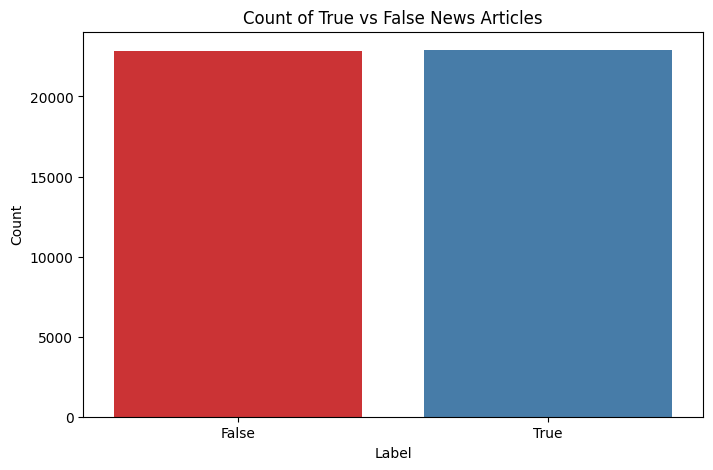

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the count of each label using the updated seaborn API
plt.figure(figsize=(8, 5))
sns.countplot(x='label', hue='label', data=df, palette='Set1', legend=False)
plt.title('Count of True vs False News Articles')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [6]:
df["text_length"] = df["text"].apply(len)
df

,text,label,text_length
0,Gere faults Trump for blurring meaning of 'ref...,True,2302
1,German parties start to find common ground in ...,True,2401
2,Senate Democratic leader says Attorney General...,True,642
3,"Tennis: Kyrgios fined $10,000 for Shanghai wal...",True,1890
4,Trump Threw Mar-A-Lago Fundraiser For Woman A...,False,1965
...,...,...,...
45752,Heavily-Armed Man Claiming To Be Jesus Arrest...,False,2038
45753,Evangelicals Across The Spectrum Are Clarifyin...,False,1030
45754,"Senators question Kaleo' $4,500 tag on opioid ...",True,2337
45755,CNN Does NOT Hold Back; Completely Makes Fun ...,False,3261


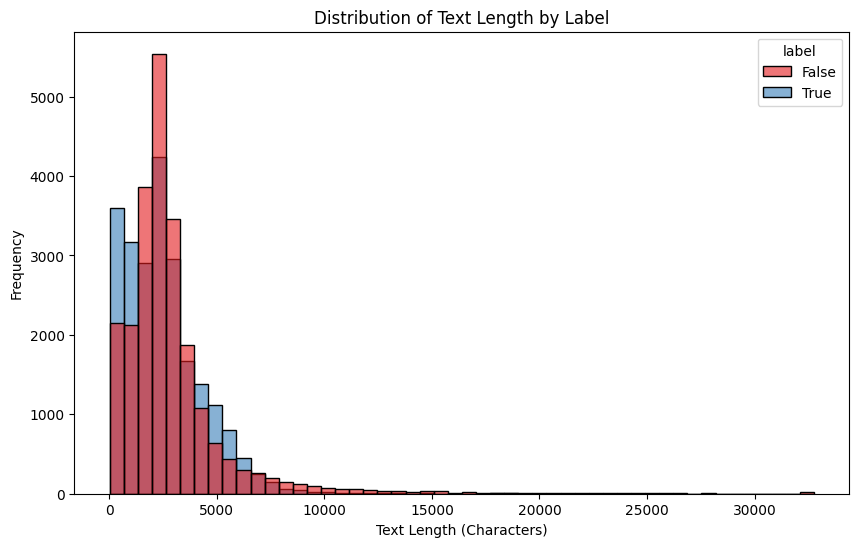

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the distribution of text_length with a high-contrast palette
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='text_length', hue='label', bins=50, palette='Set1', alpha=0.6)
plt.title('Distribution of Text Length by Label')
plt.xlabel('Text Length (Characters)')
plt.ylabel('Frequency')
plt.show()

In [8]:
df.describe(include="all")

,text,label,text_length
count,45757,45757,45757.000000
unique,45757,2,NaN
top,U.S. judge throws out Texas voter ID law suppo...,True,NaN
freq,1,22900,NaN
mean,NaN,NaN,2720.943397
std,NaN,NaN,2379.798330
min,NaN,NaN,18.000000
25%,NaN,NaN,1376.000000
50%,NaN,NaN,2325.000000
75%,NaN,NaN,3338.000000


Processing column: text


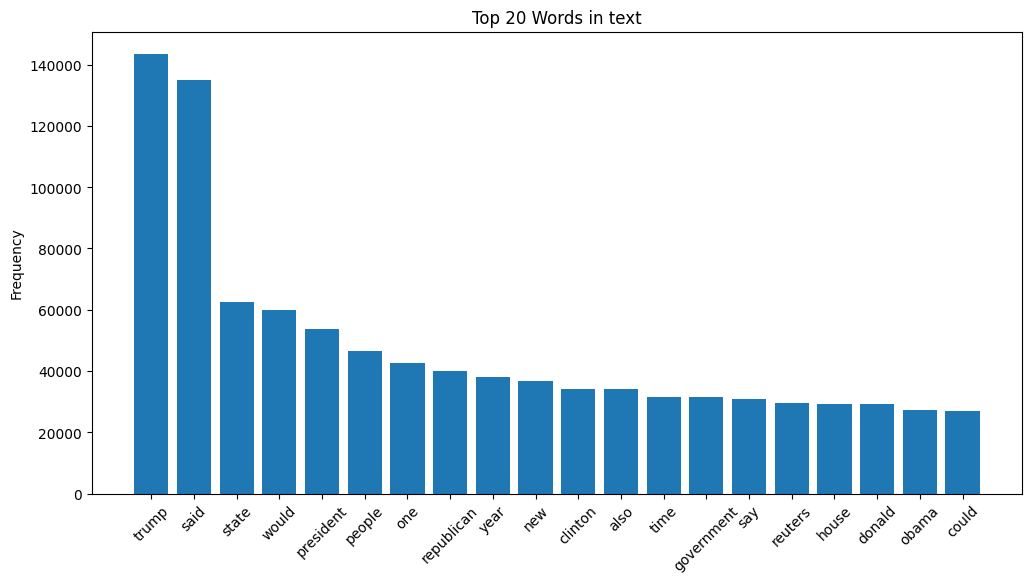

Sample of processed tokens:


,text,processed_tokens
0,Gere faults Trump for blurring meaning of 'ref...,"[gere, fault, trump, blurring, meaning, berlin..."
1,German parties start to find common ground in ...,"[german, party, start, find, common, ground, c..."
2,Senate Democratic leader says Attorney General...,"[senate, democratic, leader, say, attorney, ge..."
3,"Tennis: Kyrgios fined $10,000 for Shanghai wal...","[tennis, kyrgios, fined, shanghai, walk, tenni..."
4,Trump Threw Mar-A-Lago Fundraiser For Woman A...,"[trump, threw, fundraiser, woman, center, brib..."
...,...,...
45752,Heavily-Armed Man Claiming To Be Jesus Arrest...,"[man, claiming, jesus, arrested, plotting, kid..."
45753,Evangelicals Across The Spectrum Are Clarifyin...,"[evangelicals, across, spectrum, clarifying, m..."
45754,"Senators question Kaleo' $4,500 tag on opioid ...","[senator, question, kaleo, tag, opioid, overdo..."
45755,CNN Does NOT Hold Back; Completely Makes Fun ...,"[cnn, hold, back, completely, make, fun, paul,..."


In [9]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from collections import Counter
import matplotlib.pyplot as plt

# Download necessary NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Explicitly select the 'text' column
text_column = 'text' if 'text' in df.columns else df.columns[0]
print(f"Processing column: {text_column}")

# Initialize tools
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return []
    # Tokenization & Lowercasing
    tokens = word_tokenize(text.lower())
    # Stop word removal & non-alphabetic filtering
    filtered_tokens = [w for w in tokens if w.isalpha() and w not in stop_words]
    # Lemmatization
    lemmatized = [lemmatizer.lemmatize(w) for w in filtered_tokens]
    return lemmatized

# Apply processing
df['processed_tokens'] = df[text_column].apply(preprocess_text)

# Frequency Analysis
all_words = [word for tokens in df['processed_tokens'] for word in tokens]
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

# Visualization
if common_words:
    words, counts = zip(*common_words)
    plt.figure(figsize=(12, 6))
    plt.bar(words, counts)
    plt.title(f'Top 20 Words in {text_column}')
    plt.xticks(rotation=45)
    plt.ylabel('Frequency')
    plt.show()
else:
    print("No words found to plot.")

print("Sample of processed tokens:")
df[[text_column, 'processed_tokens']]

The NLP pipeline is complete. Here is the summary of the data wrangling and EDA:
1. Preprocessing: The text was tokenized, converted to lowercase, and stripped of non-alphabetic characters.
2. Noise Reduction: Stop words were removed, and the words were lemmatized (e.g., 'faults' became 'fault') to ensure better grouping.
3. Insights: The frequency analysis reveals that 'Trump', 'said', and 'state' are the most frequent terms in this dataset, which is typical for news-related content.

You can see the sample of the `processed_tokens` column in the output, which shows the final cleaned list of words for each row.

In [10]:
df

,text,label,text_length,processed_tokens
0,Gere faults Trump for blurring meaning of 'ref...,True,2302,"[gere, fault, trump, blurring, meaning, berlin..."
1,German parties start to find common ground in ...,True,2401,"[german, party, start, find, common, ground, c..."
2,Senate Democratic leader says Attorney General...,True,642,"[senate, democratic, leader, say, attorney, ge..."
3,"Tennis: Kyrgios fined $10,000 for Shanghai wal...",True,1890,"[tennis, kyrgios, fined, shanghai, walk, tenni..."
4,Trump Threw Mar-A-Lago Fundraiser For Woman A...,False,1965,"[trump, threw, fundraiser, woman, center, brib..."
...,...,...,...,...
45752,Heavily-Armed Man Claiming To Be Jesus Arrest...,False,2038,"[man, claiming, jesus, arrested, plotting, kid..."
45753,Evangelicals Across The Spectrum Are Clarifyin...,False,1030,"[evangelicals, across, spectrum, clarifying, m..."
45754,"Senators question Kaleo' $4,500 tag on opioid ...",True,2337,"[senator, question, kaleo, tag, opioid, overdo..."
45755,CNN Does NOT Hold Back; Completely Makes Fun ...,False,3261,"[cnn, hold, back, completely, make, fun, paul,..."


In [11]:
df["word_count"] = df["processed_tokens"].apply(len)
df

,text,label,text_length,processed_tokens,word_count
0,Gere faults Trump for blurring meaning of 'ref...,True,2302,"[gere, fault, trump, blurring, meaning, berlin...",196
1,German parties start to find common ground in ...,True,2401,"[german, party, start, find, common, ground, c...",242
2,Senate Democratic leader says Attorney General...,True,642,"[senate, democratic, leader, say, attorney, ge...",58
3,"Tennis: Kyrgios fined $10,000 for Shanghai wal...",True,1890,"[tennis, kyrgios, fined, shanghai, walk, tenni...",170
4,Trump Threw Mar-A-Lago Fundraiser For Woman A...,False,1965,"[trump, threw, fundraiser, woman, center, brib...",160
...,...,...,...,...,...
45752,Heavily-Armed Man Claiming To Be Jesus Arrest...,False,2038,"[man, claiming, jesus, arrested, plotting, kid...",179
45753,Evangelicals Across The Spectrum Are Clarifyin...,False,1030,"[evangelicals, across, spectrum, clarifying, m...",92
45754,"Senators question Kaleo' $4,500 tag on opioid ...",True,2337,"[senator, question, kaleo, tag, opioid, overdo...",203
45755,CNN Does NOT Hold Back; Completely Makes Fun ...,False,3261,"[cnn, hold, back, completely, make, fun, paul,...",279


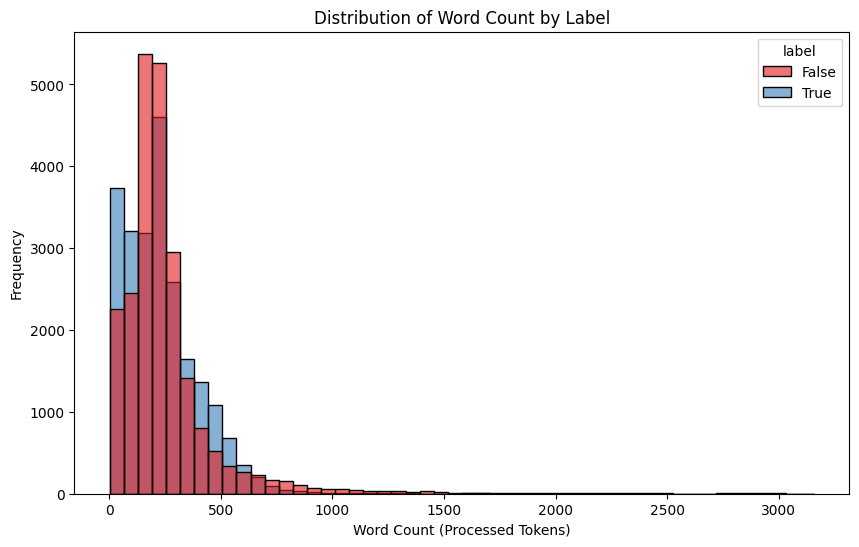

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the distribution of word_count comparing labels
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', hue='label', bins=50, palette='Set1', alpha=0.6)
plt.title('Distribution of Word Count by Label')
plt.xlabel('Word Count (Processed Tokens)')
plt.ylabel('Frequency')
plt.show()

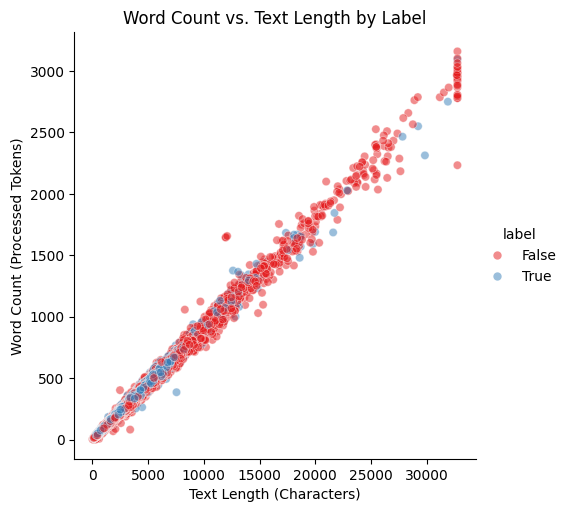

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a relplot of word_count vs text_length, color-coded by label
sns.relplot(
    x='text_length',
    y='word_count',
    hue='label',
    data=df,
    kind='scatter',
    alpha=0.5,
    palette='Set1'
)

plt.title('Word Count vs. Text Length by Label')
plt.xlabel('Text Length (Characters)')
plt.ylabel('Word Count (Processed Tokens)')
plt.show()

In [16]:
from scipy import stats
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = stats.linregress(df['text_length'], df['word_count'])

# 2. Generate predictions based on the linear model
y_pred = slope * df['text_length'] + intercept
y_true = df['word_count']

# 3. Calculate Regression Metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r_value**2

print(f"--- Regression Metrics: text_length -> word_count ---")
print(f"Mean Absolute Error (MAE):    {mae:.4f}")
print(f"Mean Squared Error (MSE):     {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (Variance explained): {r2:.4f}")

print(f"\nInterpretation: On average, our prediction is off by only {mae:.2f} words.")

--- Regression Metrics: text_length -> word_count ---
Mean Absolute Error (MAE):    10.9056
Mean Squared Error (MSE):     329.8400
Root Mean Squared Error (RMSE): 18.1615
R-squared (Variance explained): 0.9928

Interpretation: On average, our prediction is off by only 10.91 words.


Let's see if N-grams and TF-IDF can show us anything.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.util import ngrams

# 1. N-grams Analysis (Bigrams)
# Let's see the most common pairs of words
all_bigrams = list(ngrams(all_words, 2))
bigram_freq = Counter(all_bigrams)
print("--- Top 10 Bigrams ---")
for bg, count in bigram_freq.most_common(10):
    print(f"{bg}: {count}")

# 2. TF-IDF Vectorization
# This converts text into numerical vectors, weighting words by how unique they are
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
# We'll use the original text column for the vectorizer
tfidf_matrix = tfidf.fit_transform(df[text_column].head(1000)) # Using subset for speed

# Get feature names (words)
feature_names = tfidf.get_feature_names_out()

# Show top words by TF-IDF score for the first document
first_doc_scores = tfidf_matrix.getrow(0).toarray().flatten()
top_ids = first_doc_scores.argsort()[-5:][::-1]

print("\n--- Top TF-IDF words in First Document ---")
for i in top_ids:
    print(f"{feature_names[i]}: {first_doc_scores[i]:.4f}")

--- Top 10 Bigrams ---
('donald', 'trump'): 27035
('united', 'state'): 19496
('white', 'house'): 15518
('hillary', 'clinton'): 11531
('new', 'york'): 9824
('north', 'korea'): 7361
('president', 'donald'): 6913
('washington', 'reuters'): 6495
('image', 'via'): 6341
('barack', 'obama'): 5403

--- Top TF-IDF words in First Document ---
refugee: 0.4757
film: 0.2854
terrorist: 0.2492
trump: 0.2436
crime: 0.1734


The presence or absence of certain words can help establish a text's subject matter, but it isn't enough to establish its truth or falsehood. It's the contexts and relationships among the words that might help us parse truth from falsehood. And for that, our best bet is a transformer.